# Étape 1 — Nettoyage & Feature Engineering
## Projet MLOps — Home Credit Default Risk

**Fichiers utilisés :**
- `application_train.csv` → données d'entraînement (avec TARGET)

## 0. Imports & Configuration

In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer  

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import mlflow
mlflow.set_tracking_uri("sqlite:////home/veron/Documents/OpenClassRoom/p6/mlflow.db")
mlflow.set_experiment("home-credit-scoring")

# File system manangement
import os

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH   = '/home/veron//Documents/OpenClassRoom/p6/dataset/'
OUTPUT_PATH = '/home/veron//Documents/OpenClassRoom/p6/dataset/'

print('✅ Imports OK')

/home/veron/Documents/OpenClassRoom/p6/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


## 1. Chargement & Exploration

In [2]:
train = pd.read_parquet(DATA_PATH + 'app_train_clean.parquet')

print(f'Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes')
print(f'\nDistribution TARGET :')
print(train['TARGET'].value_counts(normalize=True).round(3))
print(f'\nDéséquilibre : {train["TARGET"].mean()*100:.1f}% de défauts')

Train : 307,511 lignes × 251 colonnes

Distribution TARGET :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Déséquilibre : 8.1% de défauts


In [3]:
app_train = pd.read_csv(DATA_PATH + 'application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---

On a la variable TARGET, indiquant 0 : le prêt a été remboursé ou 1 : le prêt n’a pas été remboursé. 

---

# Feature Engineering

Le feature engineering recouvre deux processus :

Feature construction : créer de nouvelles variables à partir des données existantes
Feature selection : ne garder que les variables les plus importantes (réduction de dimensionnalité)

Dans ce notebook, on appliquera deux méthodes simples :

Polynomial features (combinaisons polynomiales de variables existantes)
Domain knowledge features (nouvelles variables basées sur la connaissance métier)

### 1.Fonctionnalités polynomiales

Une méthode simple de feature construction consiste à créer des puissances de variables existantes et des termes d'interaction entre elles.
Exemples avec EXT_SOURCE_1 et EXT_SOURCE_2 :

Puissances : EXT_SOURCE_1², EXT_SOURCE_2²
Interactions : EXT_SOURCE_1 × EXT_SOURCE_2, EXT_SOURCE_1² × EXT_SOURCE_2, etc.

L'idée : deux variables faibles individuellement peuvent, combinées, révéler une relation avec la cible qu'aucune n'aurait montrée seule.
On utilise PolynomialFeatures de scikit-learn sur les variables EXT_SOURCE et DAYS_BIRTH, avec un degré de 2.

In [4]:
# Séparer TARGET
poly_target = app_train['TARGET']
cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
poly_features = app_train[cols].copy()

# Imputer en gardant les noms
imputer = SimpleImputer(strategy='median')
poly_features = pd.DataFrame(imputer.fit_transform(poly_features), columns=cols)

# Polynomial Features
poly_transformer = PolynomialFeatures(degree=2)
poly_transformer.fit(poly_features)
poly_array = poly_transformer.transform(poly_features)

# Récupérer les vrais noms
poly_names = poly_transformer.get_feature_names_out(cols)
poly_df = pd.DataFrame(poly_array, columns=poly_names)
poly_df['TARGET'] = poly_target.values

# Corrélations
corr = poly_df.corr()['TARGET'].sort_values()
print('Plus fortes corrélations négatives:\n', corr.head(10))
print('Plus fortes corrélations positives:\n', corr.tail(10))

Plus fortes corrélations négatives:
 EXT_SOURCE_2 EXT_SOURCE_3   -0.193939
EXT_SOURCE_1 EXT_SOURCE_2   -0.166625
EXT_SOURCE_1 EXT_SOURCE_3   -0.164065
EXT_SOURCE_2                -0.160295
EXT_SOURCE_3                -0.155892
EXT_SOURCE_2^2              -0.149512
EXT_SOURCE_3^2              -0.141662
EXT_SOURCE_1                -0.098887
EXT_SOURCE_1^2              -0.091034
DAYS_BIRTH^2                -0.076672
Name: TARGET, dtype: float64
Plus fortes corrélations positives:
 EXT_SOURCE_3^2            -0.141662
EXT_SOURCE_1              -0.098887
EXT_SOURCE_1^2            -0.091034
DAYS_BIRTH^2              -0.076672
DAYS_BIRTH                 0.078239
EXT_SOURCE_1 DAYS_BIRTH    0.104882
EXT_SOURCE_3 DAYS_BIRTH    0.150109
EXT_SOURCE_2 DAYS_BIRTH    0.156873
TARGET                     1.000000
1                               NaN
Name: TARGET, dtype: float64


In [5]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307511, 15)


**Résultat des Polynomial Features**  
On obtient 15 features combinant les 4 variables **'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'** puissances jusqu'au degré 2 et termes d'interaction entre les variables.
On vérifie maintenant lesquelles de ces nouvelles features sont corrélées avec TARGET :

In [6]:
poly_names = poly_transformer.get_feature_names_out()
poly_df = pd.DataFrame(poly_features, columns=poly_names)
poly_df['TARGET'] = app_train['TARGET'].values

corr = poly_df.corr()['TARGET'].sort_values()
print('Plus fortes corrélations négatives:\n', corr.head(10))
print('Plus fortes corrélations positives:\n', corr.tail(10))

Plus fortes corrélations négatives:
 EXT_SOURCE_2 EXT_SOURCE_3   -0.193939
EXT_SOURCE_1 EXT_SOURCE_2   -0.166625
EXT_SOURCE_1 EXT_SOURCE_3   -0.164065
EXT_SOURCE_2                -0.160295
EXT_SOURCE_3                -0.155892
EXT_SOURCE_2^2              -0.149512
EXT_SOURCE_3^2              -0.141662
EXT_SOURCE_1                -0.098887
EXT_SOURCE_1^2              -0.091034
DAYS_BIRTH^2                -0.076672
Name: TARGET, dtype: float64
Plus fortes corrélations positives:
 EXT_SOURCE_3^2            -0.141662
EXT_SOURCE_1              -0.098887
EXT_SOURCE_1^2            -0.091034
DAYS_BIRTH^2              -0.076672
DAYS_BIRTH                 0.078239
EXT_SOURCE_1 DAYS_BIRTH    0.104882
EXT_SOURCE_3 DAYS_BIRTH    0.150109
EXT_SOURCE_2 DAYS_BIRTH    0.156873
TARGET                     1.000000
1                               NaN
Name: TARGET, dtype: float64


---

**Analyse:**
*Corrélations négatives (réduisent le risque de défaut)* : la meilleure nouvelle feature est **EXT_SOURCE_2 × EXT_SOURCE_3 (-0.194)**, légèrement meilleure que EXT_SOURCE_2 seul (-0.160) — l'interaction entre les deux scores apporte une information supplémentaire.  

*Corrélations positives (augmentent le risque)* : les interactions **EXT_SOURCE × DAYS_BIRTH** sont toutes positives, ce qui confirme que la combinaison âge + score externe capte quelque chose que ni l'âge ni le score ne voient seuls.

---

**Plusieurs des nouvelles variables ont une corrélation plus forte avec TARGET que les variables originales. Pour savoir si elles améliorent vraiment le modèle, on les ajoutera à une copie du dataset d'entraînement et on comparera les performances avec et sans ces features.**

## Domain Knowledge Features

**On crée des features "métier" basées sur une logique financière intuitive — des ratios qui pourraient capturer le risque de défaut :**  
**- CREDIT_INCOME_PERCENT : crédit / revenu un crédit élevé par rapport au revenu = plus risqué**  
**- ANNUITY_INCOME_PERCENT : mensualité / revenu une mensualité lourde = plus risqué**  
**- CREDIT_TERM : crédit / mensualité durée du prêt en mois**  
**- DAYS_EMPLOYED_PERCENT : jours employé / âge ancienneté relative dans l'emploi**  

In [7]:
app_train_domain = app_train.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

## Visualisation des Domain Knowledge Features  
On explore ces nouvelles variables avec un KDE coloré par TARGET, comme on l'a fait pour les EXT_SOURCE :  


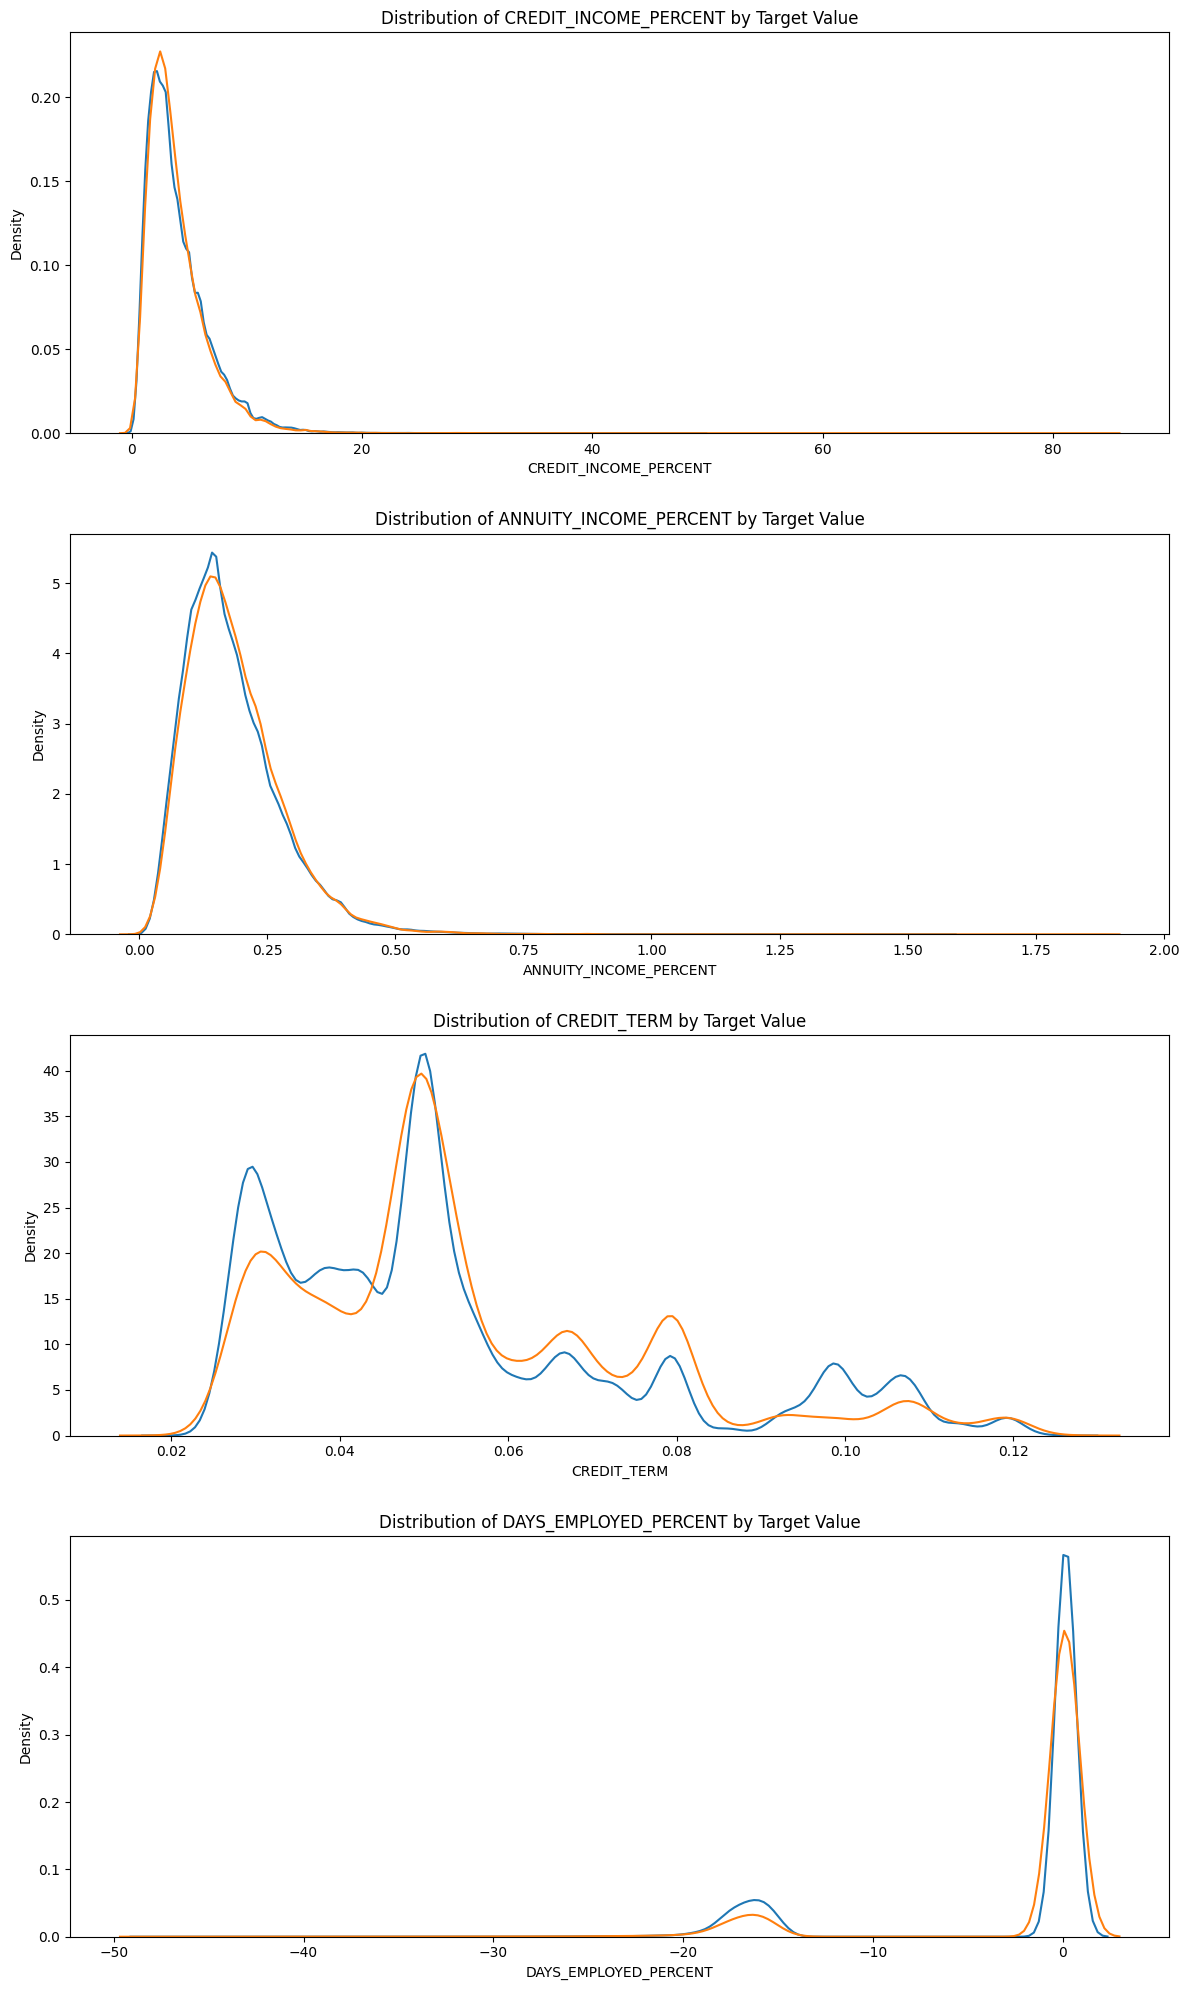

In [8]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

## Baseline 

Une baseline naïve consisterait à prédire 0.5 pour tous les clients (= incertitude totale), ce qui donne un AUC ROC de 0.5 — le score d'un modèle aléatoire. On sait déjà ce score, donc on passe directement à une baseline plus solide : la régression logistique.
On préprocesse d'abord les données en deux étapes :

Imputation : remplacement des valeurs manquantes par la médiane
Normalisation : mise à l'échelle des features (feature scaling)

In [9]:
# Drop the target from the training data
if 'TARGET' in app_train:
    train = app_train.drop(columns=['TARGET'])
else:
    train = app_train.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = le.fit_transform(train[col].astype(str))

# Feature names
features = list(train.columns)

# Median imputation of missing values
imputer = SimpleImputer(strategy='median')  # ✅ SimpleImputer au lieu de Imputer

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)

# Repeat with the scaler
scaler.fit(train)
train = scaler.transform(train)

print('Training data shape: ', train.shape)

Training data shape:  (307511, 121)


**Nous allons utiliser LogisticRegression de Scikit-Learn pour notre premier modèle.   
Le seul changement que nous apporterons par rapport aux paramètres par défaut sera de réduire le paramètre de régularisation, C, qui contrôle le degré de surapprentissage (une valeur plus faible devrait le réduire). Cela nous donnera des résultats légèrement meilleurs que la LogisticRegression par défaut, mais cela constituera tout de même une barre basse pour les modèles futurs.  
Nous utilisons ici la syntaxe de modélisation habituelle de Scikit-Learn : nous créons d'abord le modèle, puis nous l'entraînons avec .fit, et enfin nous effectuons des prédictions sur les données de test avec .predict_proba (rappelons que nous voulons des probabilités et non un 0 ou 1).**

## Régression Logistique  
utilisation de **mlflow.start_run()**

In [10]:
import mlflow
# Récupération de la target
labels = app_train['TARGET']

# Split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    train, labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels  # ✅ Important : conserve la proportion de classes déséquilibrées
)

# Création du modèle
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="LogisticRegression"):
    log_reg = LogisticRegression(
        C=0.0001,          
        class_weight='balanced',  
        random_state=42,
        max_iter=1000
    )
    
    # Entraînement
    log_reg.fit(X_train, y_train)
    
    # Prédiction des probabilités sur le set de validation
    log_reg_pred = log_reg.predict_proba(X_val)[:, 1]  # Probabilité de la classe 1 (défaut)
    
    # Évaluation
    auc_score = roc_auc_score(y_val, log_reg_pred)
    mlflow.log_metric("auc_val", auc_score)
    print(f'AUC-ROC sur la validation : {auc_score:.4f}')

2026/03/13 16:41:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/13 16:42:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/13 16:42:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


AUC-ROC sur la validation : 0.7144


La courbe **ROC** trace le taux de vrais positifs (bons clients correctement identifiés) contre le taux de faux positifs (bons clients incorrectement rejetés) pour tous les seuils de décision possibles (de 0 à 1).L'**AUC** (Area Under the Curve) est simplement l'aire sous cette courbe.  

Parce que la régression logistique est un modèle très simple, linéaire, qui ne capture pas les relations complexes entre les variables. Le fait qu'il atteigne déjà 0.71 montre que les données contiennent un signal exploitable, et que les modèles plus puissants comme LightGBM pourront en tirer bien davantage.



Maintenant que le modèle a été entraîné, nous pouvons l'utiliser pour faire des prédictions. Nous souhaitons prédire les probabilités de non-remboursement d'un prêt, nous utilisons donc la méthode predict_proba du modèle. Celle-ci retourne un tableau de dimension m × 2, où m est le nombre d'observations. La première colonne représente la probabilité que la cible soit 0, et la deuxième colonne la probabilité que la cible soit 1 (ainsi, pour une même ligne, les deux colonnes doivent sommer à 1). Nous voulons la probabilité que le prêt ne soit pas remboursé, donc nous sélectionnons la deuxième colonne.

## XGBoost

In [11]:
import mlflow
print(mlflow.__version__)
mlflow.end_run()

3.10.0


In [12]:
mlflow.xgboost.autolog(log_models=True) 

with mlflow.start_run(run_name="XGBoost") as run:
    xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=12,  # équivalent class_weight='balanced' pour XGBoost
        random_state=42,
        eval_metric='auc'
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict_proba(X_val)[:, 1]
    auc_score = roc_auc_score(y_val, xgb_pred)
    mlflow.log_metric("auc_val", auc_score)

    # ← Sauvegarder le modèle explicitement (double sécurité)
    logged_model = mlflow.xgboost.log_model(
        xgb,
        name="xgboost_model",
        registered_model_name="home_credit_scoring"  # ← enregistre en une étape
    )
    print(f'AUC-ROC sur la validation : {auc_score:.4f}')

2026/03/13 16:42:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 16:42:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/13 16:42:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


AUC-ROC sur la validation : 0.7537


Registered model 'home_credit_scoring' already exists. Creating a new version of this model...
Created version '2' of model 'home_credit_scoring'.


In [13]:
# Prédiction des probabilités sur le set de validation
log_reg_pred = log_reg.predict_proba(X_val)[:, 1]

# Récupération des SK_ID_CURR correspondant au set de validation
val_ids = app_train.iloc[X_val if isinstance(X_val, list) else y_val.index]['SK_ID_CURR'] \
    if 'SK_ID_CURR' in app_train.columns else y_val.index

# Création du dataframe de soumission
submit = pd.DataFrame({
    'SK_ID_CURR': val_ids.values,
    'TARGET': log_reg_pred
})

print(submit.head())
print(submit.shape)

   SK_ID_CURR    TARGET
0      396899  0.438433
1      322041  0.503602
2      220127  0.550364
3      251531  0.581799
4      345558  0.567131
(61503, 2)


Les prédictions doivent être au format indiqué dans le fichier sample_submission.csv, qui ne contient que deux colonnes : SK_ID_CURR et TARGET. Nous allons créer un dataframe dans ce format à partir du set de test et des prédictions, que nous appellerons submit.

In [14]:
# Dataframe de soumission basé sur le set de validation
submit = pd.DataFrame({
    'SK_ID_CURR': app_train.loc[y_val.index, 'SK_ID_CURR'].values,
    'TARGET': log_reg_pred
})

submit.head()

,SK_ID_CURR,TARGET
0,396899,0.438433
1,322041,0.503602
2,220127,0.550364
3,251531,0.581799
4,345558,0.567131


Les prédictions représentent une probabilité entre 0 et 1 que le prêt ne soit pas remboursé. Si nous utilisions ces prédictions pour classifier les demandeurs, nous pourrions définir un seuil de probabilité pour déterminer qu'un prêt est risqué.

In [15]:
# Sauvegarde des prédictions
submit.to_csv('log_reg_baseline.csv', index=False)
print("Fichier sauvegardé !")
print(submit.head())

# Évaluation locale puisqu'on a les vraies valeurs
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_val, log_reg_pred)
print(f"\nAUC-ROC sur la validation : {auc:.4f}")

Fichier sauvegardé !
   SK_ID_CURR    TARGET
0      396899  0.438433
1      322041  0.503602
2      220127  0.550364
3      251531  0.581799
4      345558  0.567131

AUC-ROC sur la validation : 0.7144


La soumission a maintenant été sauvegardée. Pour accéder au fichier sur Kaggle, il faudrait cliquer sur le bouton bleu Commit & Run en haut à droite du kernel, ce qui exécute l'ensemble du notebook et permet de télécharger les fichiers générés. Les fichiers créés sont ensuite disponibles dans l'onglet Versions sous le sous-onglet Output.

## Model Random Forest  
Pour tenter de dépasser les faibles performances de notre baseline, nous pouvons changer d'algorithme. Essayons d'utiliser un Random Forest sur les mêmes données d'entraînement pour voir comment cela affecte les performances. Le Random Forest est un modèle bien plus puissant, surtout lorsqu'on utilise des centaines d'arbres. Nous utiliserons ici 100 arbres.

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Création du Random Forest
with mlflow.start_run(run_name="RandomForest_baseline"):
    mlflow.log_param("n_estimators", 10)
    random_forest = RandomForestClassifier(n_estimators=10,random_state=50, 
    verbose=1, 
    n_jobs=-1 
)

# Entraînement
random_forest.fit(X_train, y_train)

# Extraction des feature importances
feature_importance_values = random_forest.feature_importances_
feature_importances = pd.DataFrame({
    'feature': features, 
    'importance': feature_importance_values
}).sort_values('importance', ascending=False)

print(feature_importances.head(10))

# Prédictions sur le set de validation
predictions = random_forest.predict_proba(X_val)[:, 1]

# Évaluation
auc = roc_auc_score(y_val, predictions)
mlflow.log_metric("auc_val", auc)
mlflow.sklearn.log_model(random_forest, name="rf_model")
print(f"\nAUC-ROC Random Forest : {auc:.4f}")

# Sauvegarde
submit_rf = pd.DataFrame({
    'SK_ID_CURR': app_train.loc[y_val.index, 'SK_ID_CURR'].values,
    'TARGET': predictions
})
submit_rf.to_csv('random_forest_baseline.csv', index=False)
print("Fichier sauvegardé !")

2026/03/13 16:42:49 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '78845b207b76497ca4d2eb09935107f0', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/13 16:43:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    6.7s remaining:    4.5s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    9.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.0s finished
2026/03/13 16:43:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires ex

                   feature  importance
41            EXT_SOURCE_2    0.056045
42            EXT_SOURCE_3    0.050716
16              DAYS_BIRTH    0.036523
19         DAYS_ID_PUBLISH    0.035355
18       DAYS_REGISTRATION    0.035303
0               SK_ID_CURR    0.034385
17           DAYS_EMPLOYED    0.032563
8              AMT_ANNUITY    0.032437
94  DAYS_LAST_PHONE_CHANGE    0.030891
7               AMT_CREDIT    0.030272


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.2s finished
2026/03/13 16:43:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/13 16:43:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



AUC-ROC Random Forest : 0.6335
Fichier sauvegardé !


Ce modèle a obtenu un score de 0.678 lors de la soumission à la compétition, exactement le même que celui sans les features construites. Au vu de ces résultats, il semblerait que notre construction de features n'ait pas apporté d'amélioration dans ce cas.

Ce que montrent tes résultats de feature importance :
Les variables les plus importantes sont :

EXT_SOURCE_2 et EXT_SOURCE_3 : scores externes de crédit, de loin les plus prédictifs
DAYS_BIRTH : l'âge du client (plus on est âgé, plus on est fiable)
DAYS_ID_PUBLISH, DAYS_REGISTRATION, DAYS_EMPLOYED : ancienneté de divers documents/emploi
AMT_ANNUITY, AMT_CREDIT : montants financiers

⚠️ À noter : SK_ID_CURR apparaît en 6ème position, ce qui est un signal d'alarme — c'est un simple identifiant client qui ne devrait avoir aucun pouvoir prédictif. Il faudrait le retirer des features pour éviter tout risque de data leakage :



In [17]:
# Retirer SK_ID_CURR des features
#train_clean = pd.DataFrame(train, columns=features).drop(columns=['SK_ID_CURR'])
#features_clean = list(train_clean.columns)

## Feature métier

In [18]:
from sklearn.impute import SimpleImputer

# On suppose que app_train_domain a déjà été créé avec les features métier
# et qu'il contient encore la TARGET
if 'TARGET' in app_train_domain.columns:
    app_train_domain = app_train_domain.drop(columns='TARGET')

le = LabelEncoder()
for col in app_train_domain.columns:
    if app_train_domain[col].dtype == 'object':
        app_train_domain[col] = le.fit_transform(
            app_train_domain[col].astype(str)
        )

domain_features_names = list(app_train_domain.columns)

# Split train/val sur les features métier en utilisant le même index
X_domain_train = app_train_domain.loc[y_train.index]
X_domain_val = app_train_domain.loc[y_val.index]

# Imputation
imputer = SimpleImputer(strategy='median')
X_domain_train = imputer.fit_transform(X_domain_train)
X_domain_val = imputer.transform(X_domain_val)

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
X_domain_train = scaler.fit_transform(X_domain_train)
X_domain_val = scaler.transform(X_domain_val)

# Modèle Random Forest sur les features métier
random_forest_domain = RandomForestClassifier(
    n_estimators=100, 
    random_state=50, 
    verbose=1, 
    n_jobs=-1
)

random_forest_domain.fit(X_domain_train, y_train)

# Feature importances
feature_importance_values_domain = random_forest_domain.feature_importances_
feature_importances_domain = pd.DataFrame({
    'feature': domain_features_names, 
    'importance': feature_importance_values_domain
}).sort_values('importance', ascending=False)

print(feature_importances_domain)

# Prédictions et évaluation
predictions_domain = random_forest_domain.predict_proba(X_domain_val)[:, 1]
auc_domain = roc_auc_score(y_val, predictions_domain)
print(f"\nAUC-ROC Random Forest (features métier) : {auc_domain:.4f}")

# Sauvegarde
submit_domain = pd.DataFrame({
    'SK_ID_CURR': app_train.loc[y_val.index, 'SK_ID_CURR'].values,
    'TARGET': predictions_domain
})
submit_domain.to_csv('random_forest_baseline_domain.csv', index=False)
print("Fichier sauvegardé !")

2026/03/13 16:43:48 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
2026/03/13 16:44:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/13 16:45

               feature    importance
41        EXT_SOURCE_2  5.102411e-02
42        EXT_SOURCE_3  4.739168e-02
16          DAYS_BIRTH  3.204262e-02
19     DAYS_ID_PUBLISH  3.146128e-02
18   DAYS_REGISTRATION  3.061104e-02
..                 ...           ...
110   FLAG_DOCUMENT_17  2.313857e-05
97     FLAG_DOCUMENT_4  2.457782e-07
21          FLAG_MOBIL  0.000000e+00
105   FLAG_DOCUMENT_12  0.000000e+00
103   FLAG_DOCUMENT_10  0.000000e+00

[125 rows x 2 columns]


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.8s finished



AUC-ROC Random Forest (features métier) : 0.7134
Fichier sauvegardé !


Le Random Forest sans features métier performe moins bien que la simple régression logistique, ce qui est surprenant. Cela peut s'expliquer par le fait que le preprocessing initial (encodage, imputation) n'est pas optimal pour le Random Forest.
Les features métier rattrapent presque entièrement cet écart (+0.08 d'AUC).
La régression logistique reste légèrement meilleure que les deux Random Forest, ce qui confirme qu'on est encore loin du potentiel réel des données.

La suite logique est de passer à LightGBM ou XGBoost qui devraient franchir la barre des 0.75-0.78, et qui sont nativement plus robustes aux variables catégorielles et aux valeurs manquantes — ce qui explique en partie pourquoi le Random Forest sous-performe ici.

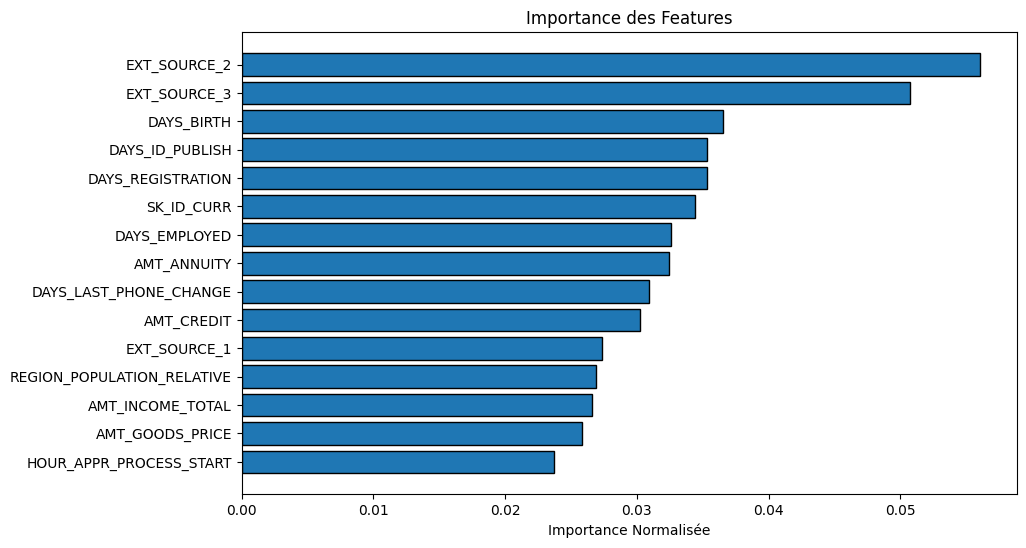

In [19]:
import matplotlib.pyplot as plt

def plot_feature_importances(df):
    """
    Affiche les importances retournées par un modèle.
    
    Args:
        df (dataframe): importances des features. Doit avoir les features 
        dans une colonne 'feature' et les importances dans 'importance'
        
    Returns:
        Affiche un graphique des 15 features les plus importantes
        df (dataframe): features triées par importance (desc) avec importance normalisée
    """
    # Tri par importance décroissante
    df = df.sort_values('importance', ascending=False).reset_index()
    
    # Normalisation des importances (somme = 1)
    df['importance_normalized'] = df['importance'] / df['importance'].sum()
    
    # Graphique horizontal
    plt.figure(figsize=(10, 6))
    ax = plt.subplot()
    
    ax.barh(list(reversed(list(df.index[:15]))), 
            df['importance_normalized'].head(15), 
            align='center', edgecolor='k')
    
    ax.set_yticks(list(reversed(list(df.index[:15]))))
    ax.set_yticklabels(df['feature'].head(15))
    
    plt.xlabel('Importance Normalisée')
    plt.title('Importance des Features')
    plt.show()
    
    return df

# Affichage des feature importances
feature_importances_sorted = plot_feature_importances(feature_importances)

Comme méthode simple pour identifier les variables les plus pertinentes, nous pouvons examiner les importances des features du Random Forest. Au vu des corrélations observées lors de l'analyse exploratoire, nous devrions nous attendre à ce que les features les plus importantes soient EXT_SOURCE et DAYS_BIRTH.
Comme attendu, les features les plus importantes sont celles liées à EXT_SOURCE et DAYS_BIRTH. On constate que seules quelques features ont une importance significative, ce qui suggère qu'il serait possible d'en supprimer beaucoup sans dégradation des performances (voire avec une amélioration). Les importances de features ne sont pas la méthode la plus sophistiquée pour interpréter un modèle, mais elles permettent de commencer à comprendre quels facteurs le modèle prend en compte dans ses prédictions.

On constate que nos quatre features construites manuellement figurent toutes dans le top 15 des plus importantes ! Cela nous conforte dans l'idée que notre connaissance métier était au moins partiellement pertinente.
Conclusions
Dans ce notebook, nous avons vu comment démarrer sur une compétition Kaggle. Nous avons d'abord veillé à bien comprendre les données, notre tâche et la métrique d'évaluation. Ensuite, nous avons réalisé une EDA pour identifier des relations, tendances ou anomalies utiles à la modélisation. Nous avons effectué les étapes de preprocessing nécessaires : encodage des variables catégorielles, imputation des valeurs manquantes et normalisation des features. Puis nous avons construit de nouvelles features à partir des données existantes.
Une fois l'exploration, la préparation et le feature engineering terminés, nous avons implémenté un modèle baseline, puis un second modèle légèrement plus complexe. Nous avons également mené une expérience pour mesurer l'effet des variables construites.
Nous avons suivi le schéma général d'un projet de machine learning :

Comprendre le problème et les données
Nettoyage et formatage des données
Analyse exploratoire
Modèle baseline
Modèle amélioré
Interprétation du modèle

---
## ✅ Checklist — Étape 1

| Indicateur | Statut |
|---|---|
| Exploration données brutes | ✅ |
| Fusion train + test cohérente | ✅ |
| Suppression colonnes >40% NaN | ✅ |
| Correction anomalie DAYS_EMPLOYED | ✅ |
| Encodage variables catégorielles | ✅ |
| Nouvelles features métier | ✅ |
| Remplacement valeurs infinies | ✅ |
| Datasets sauvegardés en parquet | ✅ |